#### Import Libraries

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import  accuracy_score,confusion_matrix,classification_report,mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_digits
from ucimlrepo import fetch_ucirepo 
import warnings 
warnings.filterwarnings('ignore')

#### Load Dataset

In [62]:
abalone = fetch_ucirepo(id=1) 
  
X = abalone.data.features 
y = abalone.data.targets 
  
print(abalone.metadata) 

print(abalone.variables)

{'uci_id': 1, 'name': 'Abalone', 'repository_url': 'https://archive.ics.uci.edu/dataset/1/abalone', 'data_url': 'https://archive.ics.uci.edu/static/public/1/data.csv', 'abstract': 'Predict the age of abalone from physical measurements', 'area': 'Biology', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Tabular'], 'num_instances': 4177, 'num_features': 8, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': [], 'target_col': ['Rings'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1994, 'last_updated': 'Mon Aug 28 2023', 'dataset_doi': '10.24432/C55C7W', 'creators': ['Warwick Nash', 'Tracy Sellers', 'Simon Talbot', 'Andrew Cawthorn', 'Wes Ford'], 'intro_paper': None, 'additional_info': {'summary': 'Predicting the age of abalone from physical measurements.  The age of abalone is determined by cutting the shell through the cone, staining it, and counting the number of rings through a microscope -- 

### Checking null values

In [63]:
null_value = X.isnull().sum().sum()  
if null_value == 0:
    print("There are no missing values in the dataset.")
else:
    print(f"There are {null_value} missing values in the dataset.")



There are no missing values in the dataset.


#### Encoding coloumn

In [64]:
le = LabelEncoder()
for col in X.select_dtypes(include=['category','object']):
    X[col] = le.fit_transform(X[col])
    
X.head()

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight
0,2,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150
1,2,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070
2,0,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210
3,2,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155
4,1,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055


#### Scaling dataset

In [65]:
scalor = StandardScaler()

for col in X.select_dtypes(include=['int', 'float']).columns:
    X[col] = scalor.fit_transform(X[[col]])

X.head()   

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight
0,1.151980,-0.574558,-0.432149,-1.064424,-0.641898,-0.607685,-0.726212,-0.638217
1,1.151980,-1.448986,-1.439929,-1.183978,-1.230277,-1.170910,-1.205221,-1.212987
2,-1.280690,0.050033,0.122130,-0.107991,-0.309469,-0.463500,-0.356690,-0.207139
3,1.151980,-0.699476,-0.432149,-0.347099,-0.637819,-0.648238,-0.607600,-0.602294
4,-0.064355,-1.615544,-1.540707,-1.423087,-1.272086,-1.215968,-1.287337,-1.320757


#### Finding best K

In [66]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

k_values = [1,3,5, 7, 9, 11]
best = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    confuse = confusion_matrix(y_test, y_pred)
    best.append((k, acc))
    
best_K = max(best,key=lambda x : x[1])
print(f"Best value of K is {best_K[0]} with accuracy {best_K[1]*100:.2f}%")


Best value of K is 9 with accuracy 24.28%


#### Fit model

In [67]:
model = KNeighborsClassifier(n_neighbors=9)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mean_square = mean_squared_error(y_pred,y_test)
print(f"Mean square error : {mean_square}")

Mean square error : 7.070574162679426


#### Confusion matrix

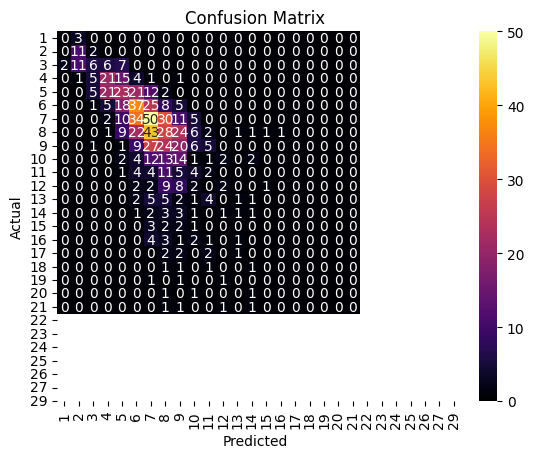

In [75]:
confuse = confusion_matrix(y_test, y_pred)

y = abalone.data.targets['Rings']
labels = sorted(y.unique())

sns.heatmap(confuse, annot=True, fmt='d', cmap='inferno', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [76]:
classify = classification_report(y_test,y_pred)
print(classify)

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.42      0.85      0.56        13
           5       0.30      0.19      0.23        32
           6       0.38      0.44      0.40        48
           7       0.27      0.27      0.27        84
           8       0.26      0.37      0.31        99
           9       0.26      0.35      0.30       142
          10       0.20      0.20      0.20       139
          11       0.20      0.22      0.21        93
          12       0.03      0.02      0.02        51
          13       0.11      0.06      0.08        31
          14       0.29      0.08      0.12        26
          15       0.20      0.05      0.08        21
          16       0.12      0.08      0.10        13
          17       0.00      0.00      0.00         8
          18       0.00      0.00      0.00        12
          19       0.00      0.00      0.00         7
          20       0.00    